## Trabajo Individual 2
### Fontanari Federico
Consigna:
1. Seleccionar uno de los sets de datos disponibles
2. Realizar un EDA básico del dataset seleccionado:<br>
    -estadística descriptiva <br>
    -tipos de variables <br>
    -identificación de duplicados, nulos, outliers <br>
    -incluir al menos 3 gráficos<br>
3. Se pueden apoyar en las notebooks dadas en clase o pueden crear su propio código.

### Dataset elegido: Pokemon Data
#### Link: https://www.kaggle.com/datasets/mlomuscio/pokemon?resource=download&select=PokemonData.csv

#### Importamos las librerias necesarias

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.precision', 2)

# Cargamos el dataset
df = pd.read_csv('PokemonData.csv')

# Revisamos los tipos de variables
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Num         800 non-null    int64 
 1   Name        800 non-null    object
 2   Type1       800 non-null    object
 3   Type2       414 non-null    object
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   SpAtk       800 non-null    int64 
 8   SpDef       800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 69.7+ KB
None


#### Variables Categóricas: 
-Name: Nombre del Pokemon <br>
-Type1 <br>
-Type2 <br>

#### Variables Numéricas: 
-num: Es el ID del Pokemon <br>
-HP <br>
-Attack  <br>
-Defense: <br>
-Sp. Atk <br>
-Sp. Def <br>
-Speed <br>
-Generation: Indica el numero de generacion a la cual pertence <br>
-Legendary: Inidca si el Pokemon es legendario <br>

In [2]:
df.head(5)

,Num,Name,Type1,Type2,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


### Duplicados

In [3]:
# Registros Duplicados:
df.duplicated().sum()

np.int64(0)

No hay registros duplicados

In [4]:
#Por Nombre:
df["Name"].duplicated().sum()

np.int64(0)

No hay duplicados por nombre

In [5]:
# Por ID:
df["Num"].duplicated().sum()

np.int64(79)

Hay duplicados por numero. Veamos algunos ejemplos:

In [6]:
df[["Num"]].value_counts()

Num
479    6
386    4
710    4
711    4
646    3
      ..
717    1
718    1
37     1
38     1
17     1
Name: count, Length: 721, dtype: int64

In [7]:
df.loc[df["Num"]==479]

,Num,Name,Type1,Type2,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation,Legendary
531,479,Rotom,Electric,Ghost,50,50,77,95,77,91,4,False
532,479,RotomHeat Rotom,Electric,Fire,50,65,107,105,107,86,4,False
533,479,RotomWash Rotom,Electric,Water,50,65,107,105,107,86,4,False
534,479,RotomFrost Rotom,Electric,Ice,50,65,107,105,107,86,4,False
535,479,RotomFan Rotom,Electric,Flying,50,65,107,105,107,86,4,False
536,479,RotomMow Rotom,Electric,Grass,50,65,107,105,107,86,4,False


In [8]:
df.loc[df["Num"]==6]

,Num,Name,Type1,Type2,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation,Legendary
6,6,Charizard,Fire,Flying,78,84,78,109,85,100,1,False
7,6,CharizardMega Charizard X,Fire,Dragon,78,130,111,130,85,100,1,False
8,6,CharizardMega Charizard Y,Fire,Flying,78,104,78,159,115,100,1,False


Analizando algunos casos, nos damos cuenta que es porque considera las "MegaEvoluciones". Vamos a quitarlas para no inflar las estadisticas de los pokemon base, ya que no son muy comunes

In [9]:
# Eliminamos los registros con el mismo 'num', dejando solo el primero
df_limpio = df.drop_duplicates(subset='Num', keep='first')

# Verificacion
print(f"Registros originales: {len(df)}")
print(f"Registros tras limpieza: {len(df_limpio)}")

Registros originales: 800
Registros tras limpieza: 721


In [10]:
# Verificamos:
df_limpio.loc[df["Num"]==6]

,Num,Name,Type1,Type2,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation,Legendary
6,6,Charizard,Fire,Flying,78,84,78,109,85,100,1,False


### Nulos

In [11]:
# Nulos por columna
print(df_limpio.isnull().sum())

Num             0
Name            0
Type1           0
Type2         371
HP              0
Attack          0
Defense         0
SpAtk           0
SpDef           0
Speed           0
Generation      0
Legendary       0
dtype: int64


Solo hay registros nulos en la variable "Type2". Esto es correcto ya que algunos pokemon solo tienen un tipo, mientras que otros tienen dos

### Estadisticas de la base

Veamos un resumen de las estadisticas de la nueva base (luego de quitar duplicados):

In [12]:
df_limpio.describe()

,Num,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation
count,721.00,721.00,721.00,721.00,721.00,721.00,721.00,721.00
mean,361.00,68.38,75.12,70.70,68.85,69.18,65.71,3.32
std,208.28,25.85,29.07,29.19,28.90,26.90,27.28,1.67
min,1.00,1.00,5.00,5.00,10.00,20.00,5.00,1.00
25%,181.00,50.00,54.00,50.00,45.00,50.00,45.00,2.00
50%,361.00,65.00,75.00,65.00,65.00,65.00,65.00,3.00
75%,541.00,80.00,95.00,85.00,90.00,85.00,85.00,5.00
max,721.00,255.00,165.00,230.00,154.00,230.00,160.00,6.00


In [13]:
# Cantidad de Pokemon por Tipo
df_limpio["Type1"].value_counts()

Type1
Water       105
Normal       93
Grass        66
Bug          63
Fire         47
Psychic      47
Rock         41
Electric     36
Ground       30
Poison       28
Dark         28
Fighting     25
Dragon       24
Ice          23
Ghost        23
Steel        22
Fairy        17
Flying        3
Name: count, dtype: int64

In [14]:
# Cantidad de Pokemon por Generacion
df_limpio["Generation"].value_counts()

Generation
5    156
1    151
3    135
4    107
2    100
6     72
Name: count, dtype: int64

In [15]:
# Cantidad de Pokemon por legendario
df_limpio["Legendary"].value_counts()

Legendary
False    675
True      46
Name: count, dtype: int64

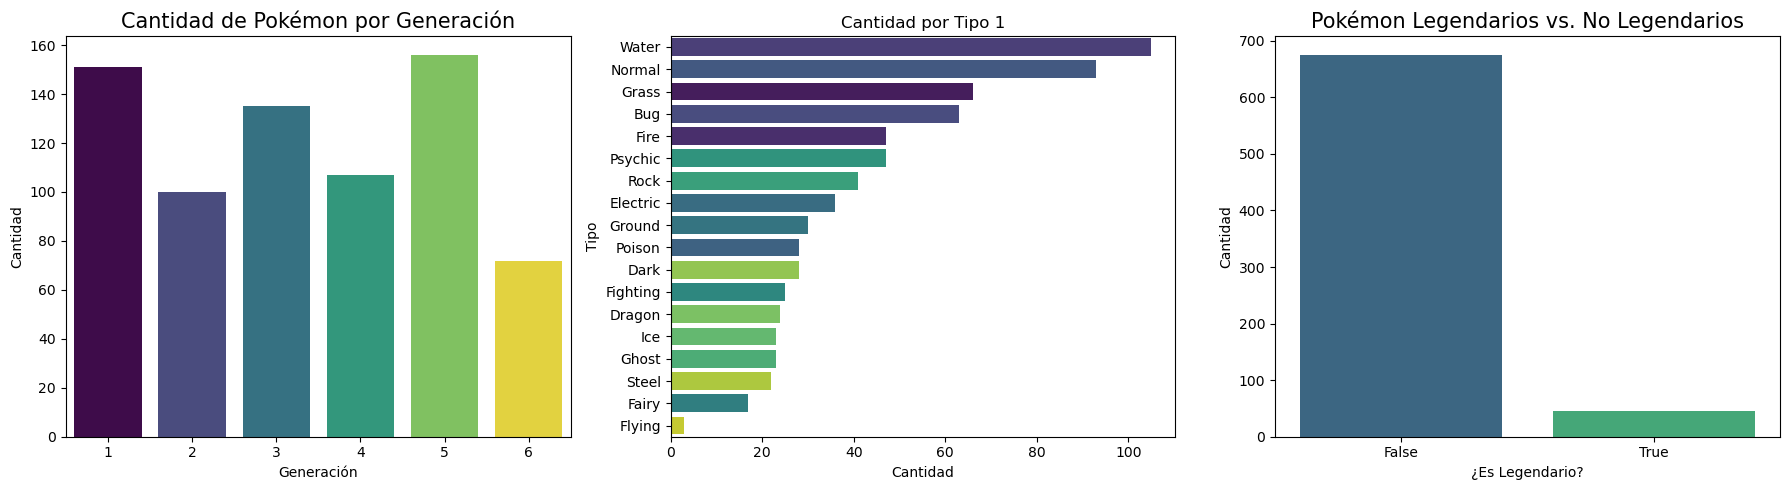

In [16]:
plt.figure(figsize=(18, 5))
# --- Grafico 1: Pokemons por Generacion ---
plt.subplot(1, 3, 1)
sns.countplot(data=df_limpio, x='Generation', hue='Generation',palette='viridis', legend=False)
plt.title('Cantidad de Pokémon por Generación', fontsize=15)
plt.xlabel('Generación')
plt.ylabel('Cantidad')

# --- Grafico 2: Pokemon por Tipo 1 ---
plt.subplot(1, 3, 2)
tipo_order = df_limpio['Type1'].value_counts().index
sns.countplot(data=df_limpio, y='Type1', order=tipo_order, hue='Type1' ,palette='viridis', legend=False)
plt.title('Cantidad por Tipo 1')
plt.xlabel('Cantidad')
plt.ylabel('Tipo')

# --- Grafico 3: Legendarios vs No Legendarios ---
plt.subplot(1, 3, 3)
sns.countplot(data=df_limpio, x='Legendary', hue='Legendary',palette='viridis', legend=False)
plt.title('Pokémon Legendarios vs. No Legendarios', fontsize=15)
plt.xlabel('¿Es Legendario?')
plt.ylabel('Cantidad')

plt.tight_layout()
plt.show()

### Veamos las distribuciones de cada estadistica

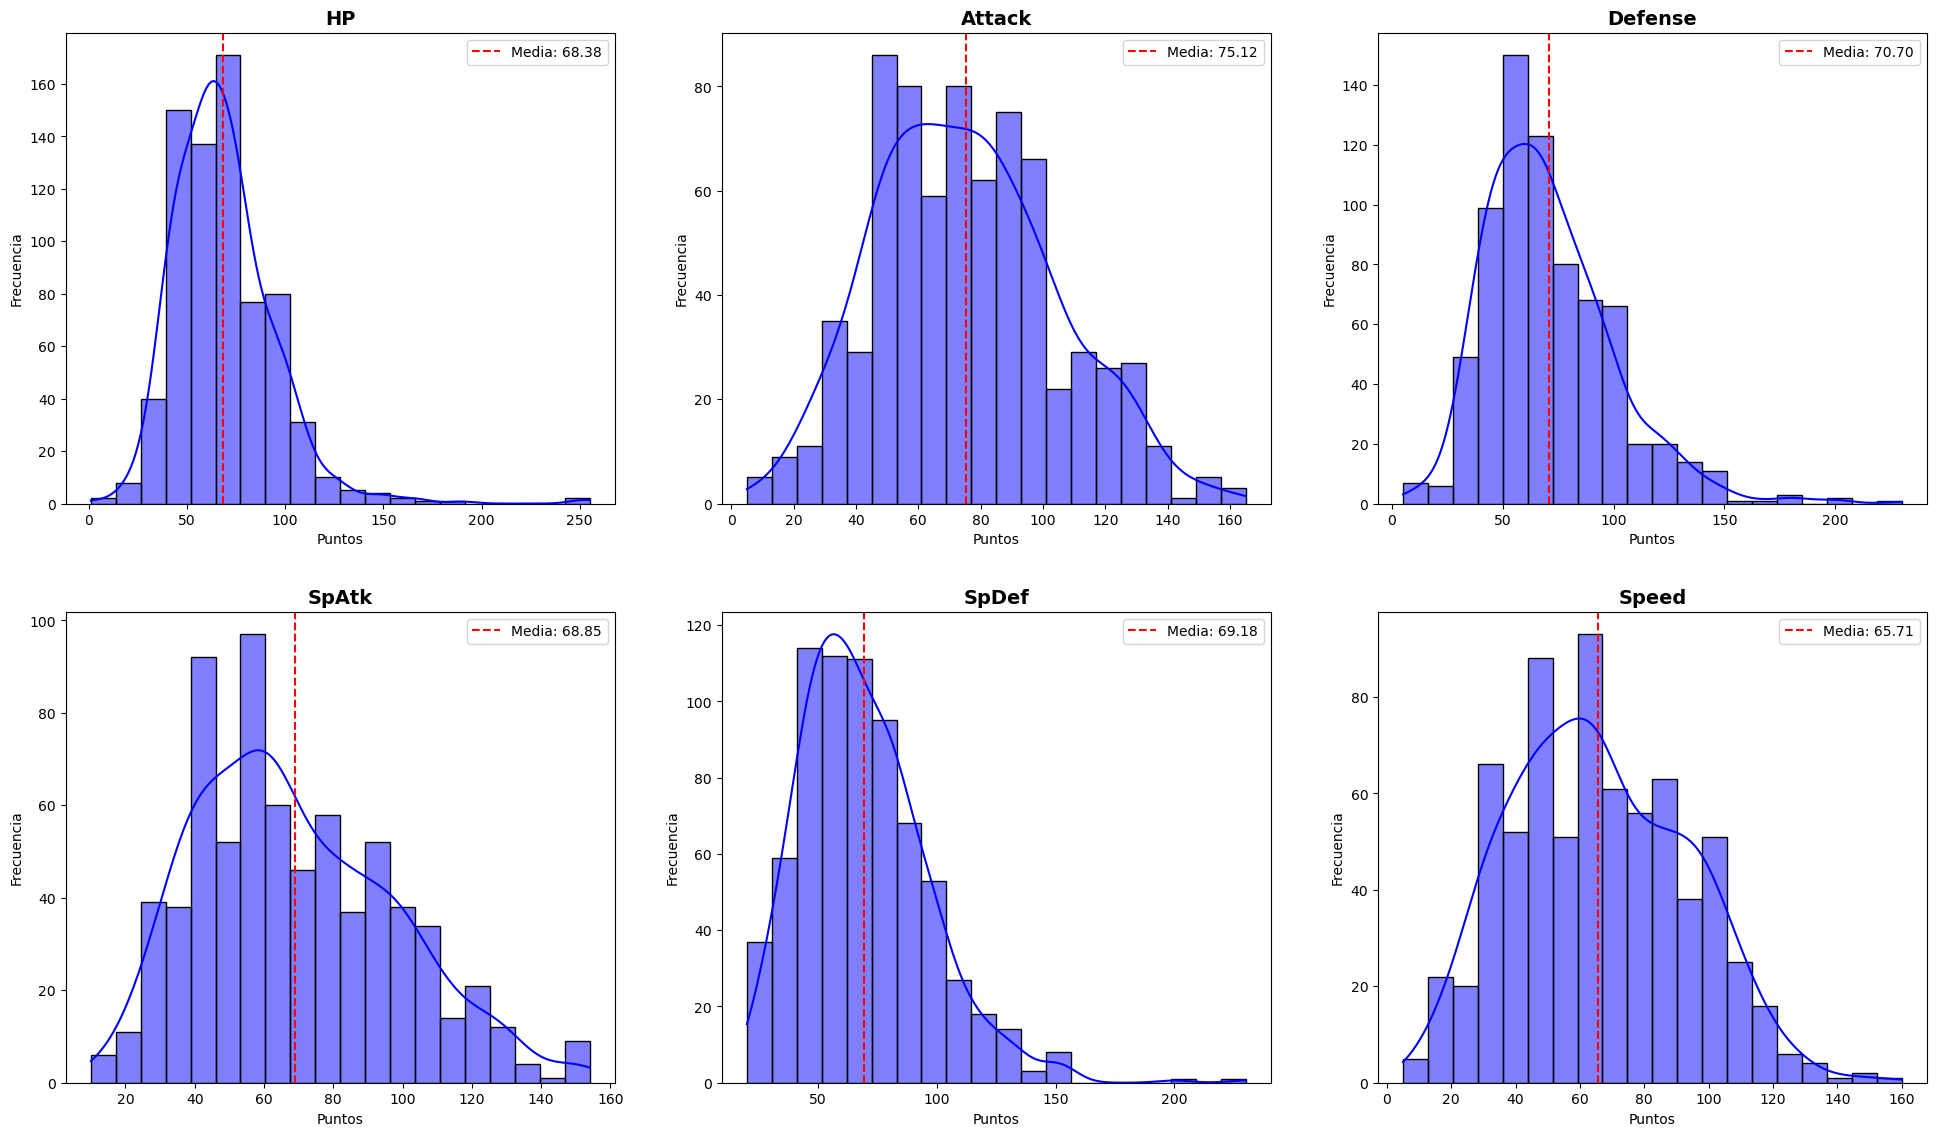

In [17]:
# Lista de estadísticas a graficar
stats = ['HP', 'Attack', 'Defense', 'SpAtk', 'SpDef', 'Speed']

# Configuramos la cuadrícula (2 filas, 3 columnas)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten() # Aplanamos para iterar fácilmente

for i, stat in enumerate(stats):
    # Generamos el histograma con la línea de densidad (kde)
    sns.histplot(df_limpio[stat], kde=True, ax=axes[i], color='blue', bins=20)
    
    # Añadimos una línea para la media (promedio)
    axes[i].axvline(df_limpio[stat].mean(), color='red', linestyle='--', label=f'Media: {df_limpio[stat].mean():.2f}')
    
    axes[i].set_title(f'{stat}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Puntos')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()

plt.tight_layout(pad=3.0)
plt.show()

### Lo mismo en BoxPlots

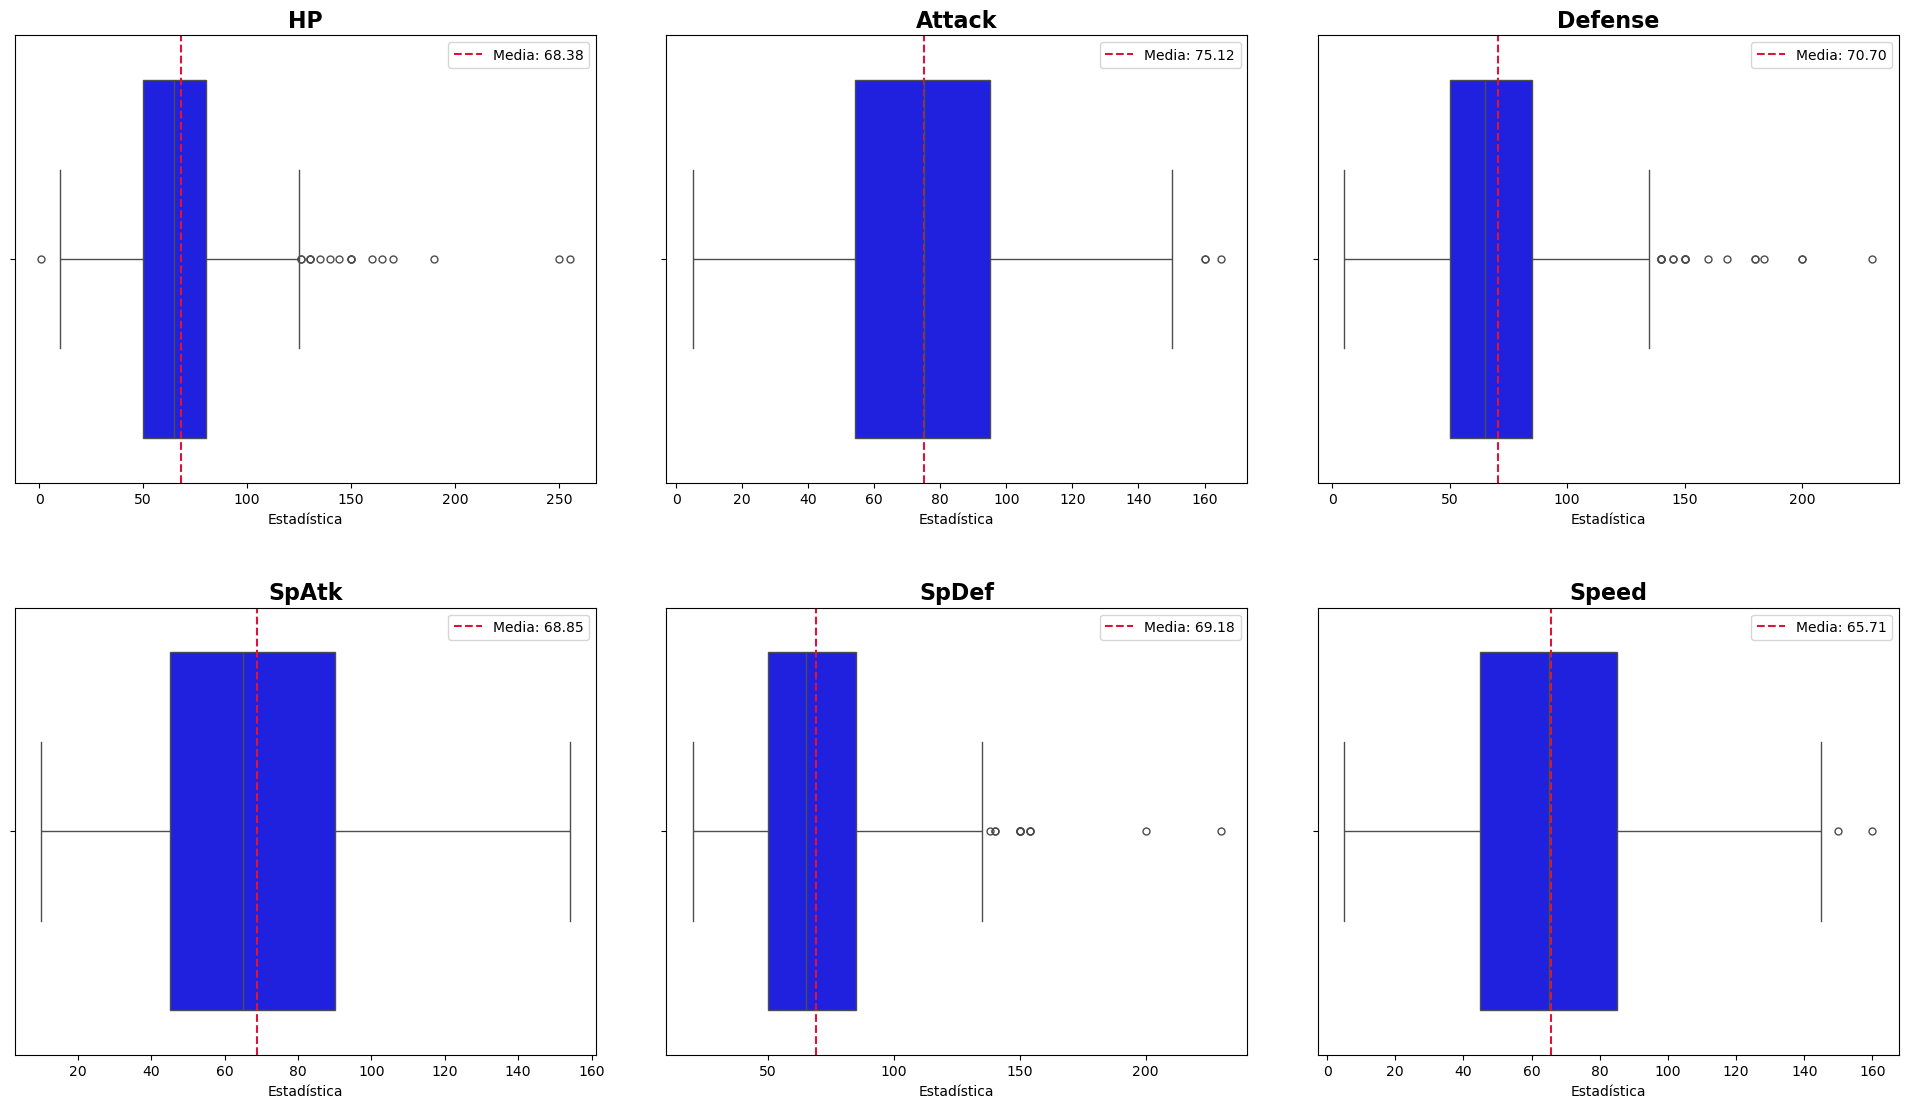

In [18]:
# Configuramos la cuadrícula (2 filas, 3 columnas)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten() # Aplanamos para iterar sobre los ejes

for i, stat in enumerate(stats):
    sns.boxplot(data=df_limpio, x=stat, ax=axes[i], color='blue', fliersize=5)

    axes[i].set_title(f'{stat}', fontsize=16, fontweight='bold')
    axes[i].set_xlabel('Estadística')
    
    # Añadimos una línea punteada para la media, ya que el boxplot muestra la mediana por defecto
    mean_val = df_limpio[stat].mean()
    axes[i].axvline(mean_val, color='crimson', linestyle='--', label=f'Media: {mean_val:.2f}')
    axes[i].legend()

# Ajustamos el espacio para que los títulos no choquen
plt.tight_layout(pad=4.0)
plt.show()

#### Podemos evaluar tambien el promedio de cada estadistica por tipo de Pokemon

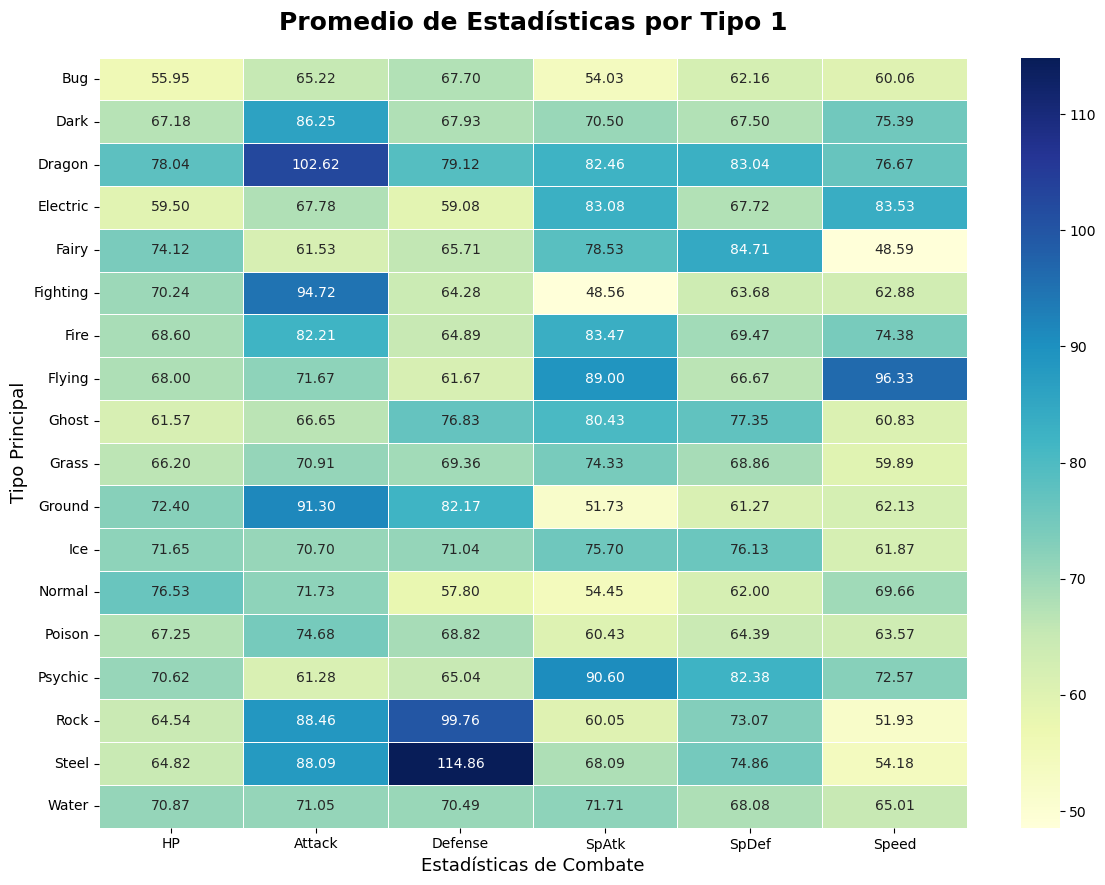

In [19]:
df_stats_by_type = df_limpio.groupby('Type1')[stats].mean().round(2)

# Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df_stats_by_type, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=.5)

# Personalización
plt.title('Promedio de Estadísticas por Tipo 1', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Estadísticas de Combate', fontsize=13)
plt.ylabel('Tipo Principal', fontsize=13)

plt.show()

Podemos observar que los que son tipo "Dragon" tienen mucho ataque, mientras que los que son tipo "Steel" tienen mucha defensa

### Veamos si hay diferencia entre los pokemon Legendarios y los que no

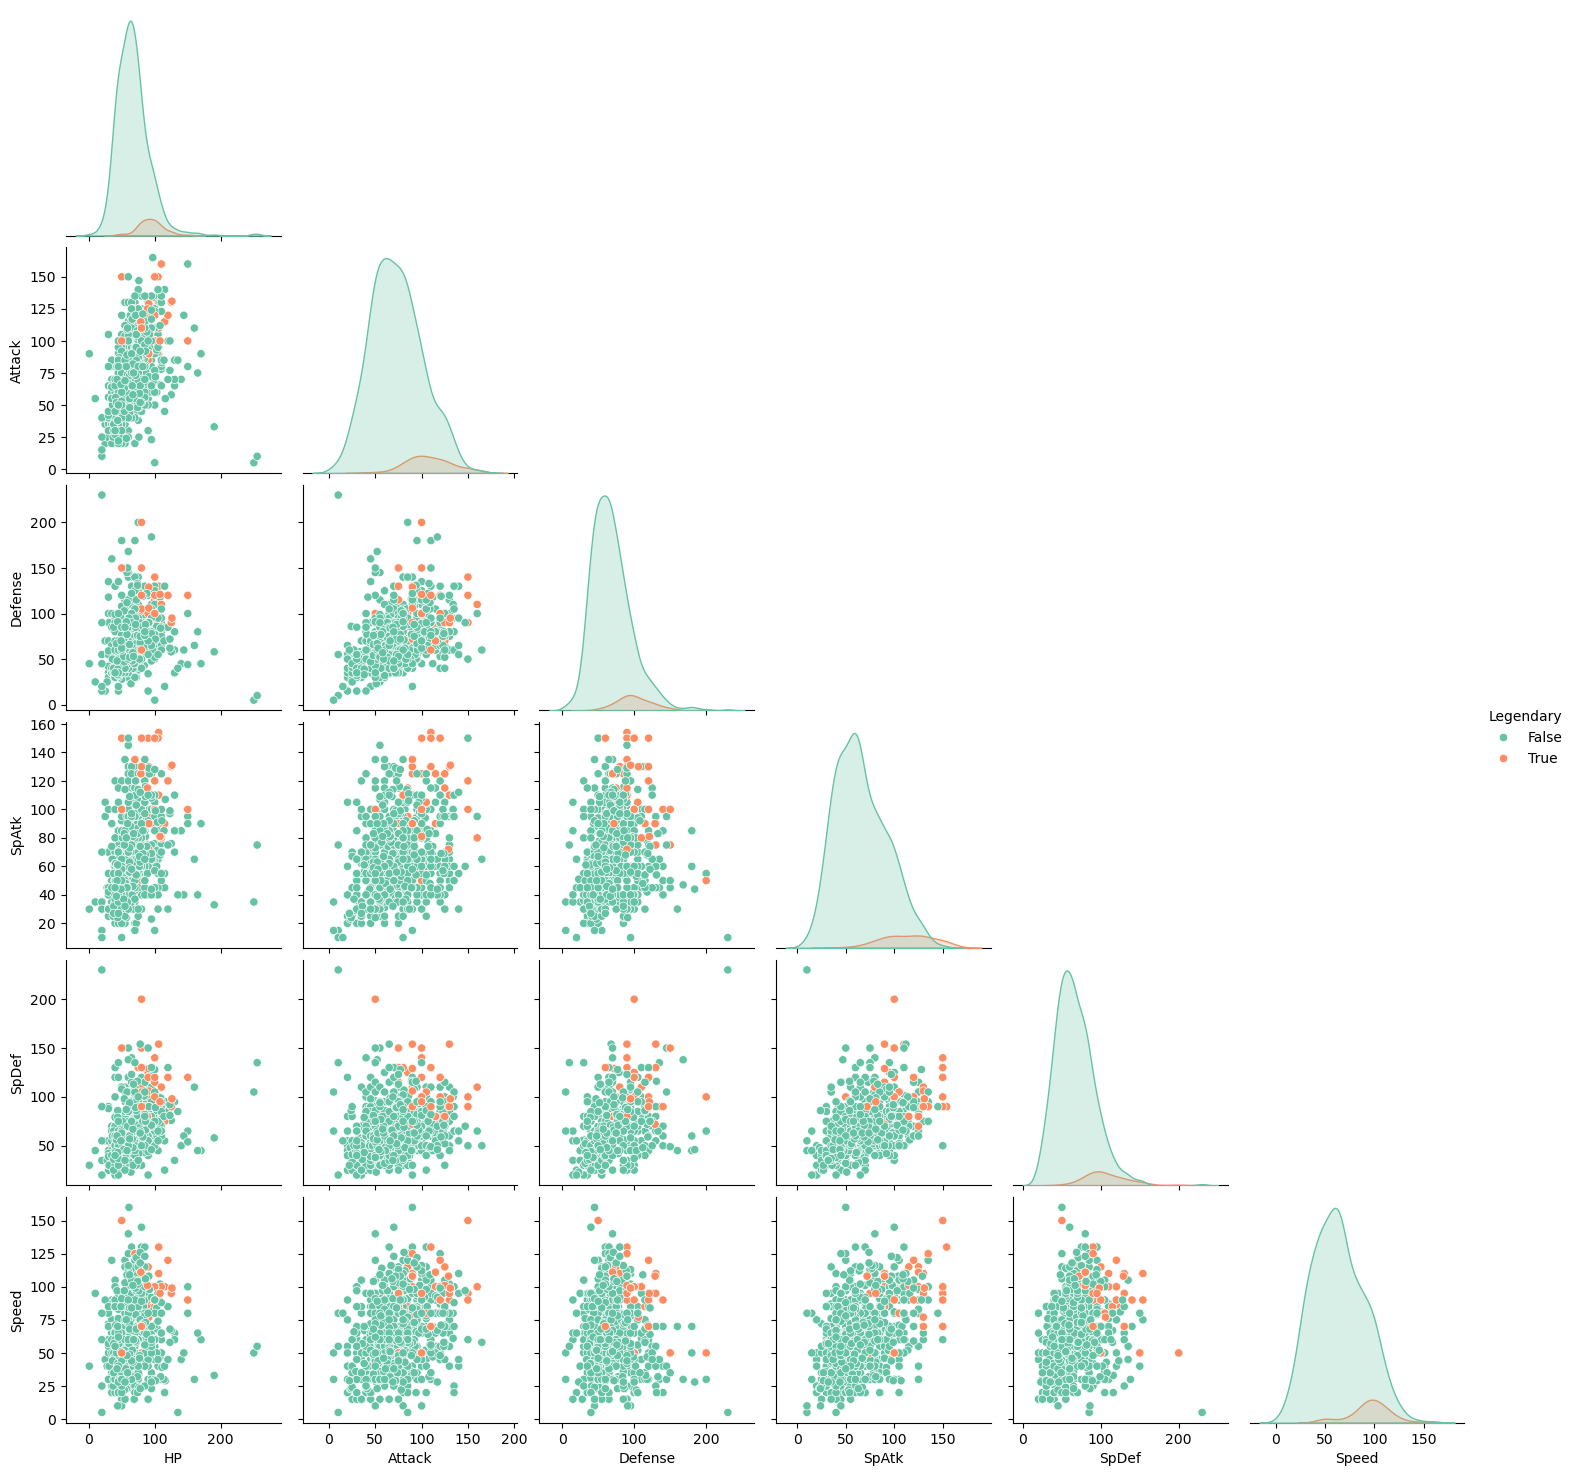

In [20]:
cols_stats = ['HP', 'Attack', 'Defense', 'SpAtk', 'SpDef', 'Speed', 'Legendary']
df_stats = df_limpio[cols_stats]
grid = sns.pairplot(df_stats, hue='Legendary', palette='Set2', diag_kind='kde', corner=True)

Se puede observar que los pokemon Legendarios tienen estadisticas mas elevadas que los que no lo son <br>
-Si evaluamos una estadistica contra otra estadistica (ejemplo HP vs Speed), los pokemon legendarios se suelen ubicar en la parte superior derecha (mayores valores para ambas estadisticas)<br>
-Si evaluamos la distriucion en general, vemos que la media se ubica mas a la derecha para cualquier caracteristica<br>

#### Por ultimo, veamos si hay alguna relacion entre el segundo tipo del pokemon y el primero

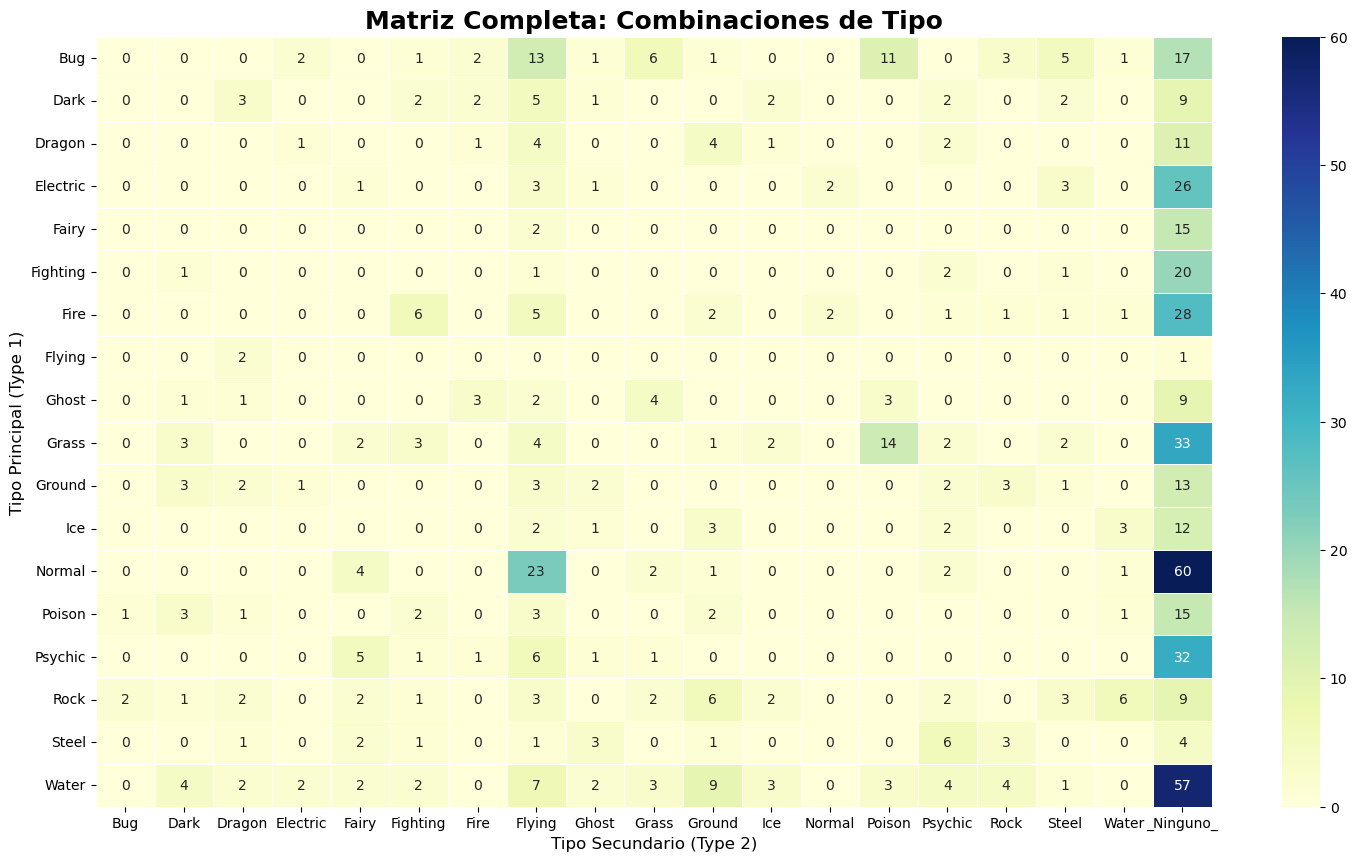

In [21]:
# Creamos una copia para no alterar el dataframe original
df_matriz = df_limpio.copy()

# Reemplazamos los nulos por la palabra "Ninguno"
df_matriz['Type2'] = df_matriz['Type2'].fillna('_Ninguno_')

matriz_completa = pd.crosstab(df_matriz['Type1'], df_matriz['Type2'])

# Graficamos
plt.figure(figsize=(18, 10))
sns.heatmap(matriz_completa, annot=True, cmap='YlGnBu', fmt='d', linewidths=.5)

plt.title('Matriz Completa: Combinaciones de Tipo', fontsize=18, fontweight='bold')
plt.xlabel('Tipo Secundario (Type 2)', fontsize=12)
plt.ylabel('Tipo Principal (Type 1)', fontsize=12)
plt.show()

C:\Users\feder\AppData\Local\Temp\ipykernel_15676\966199156.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio['Tiene_Type2'] = df_limpio['Type2'].notna()


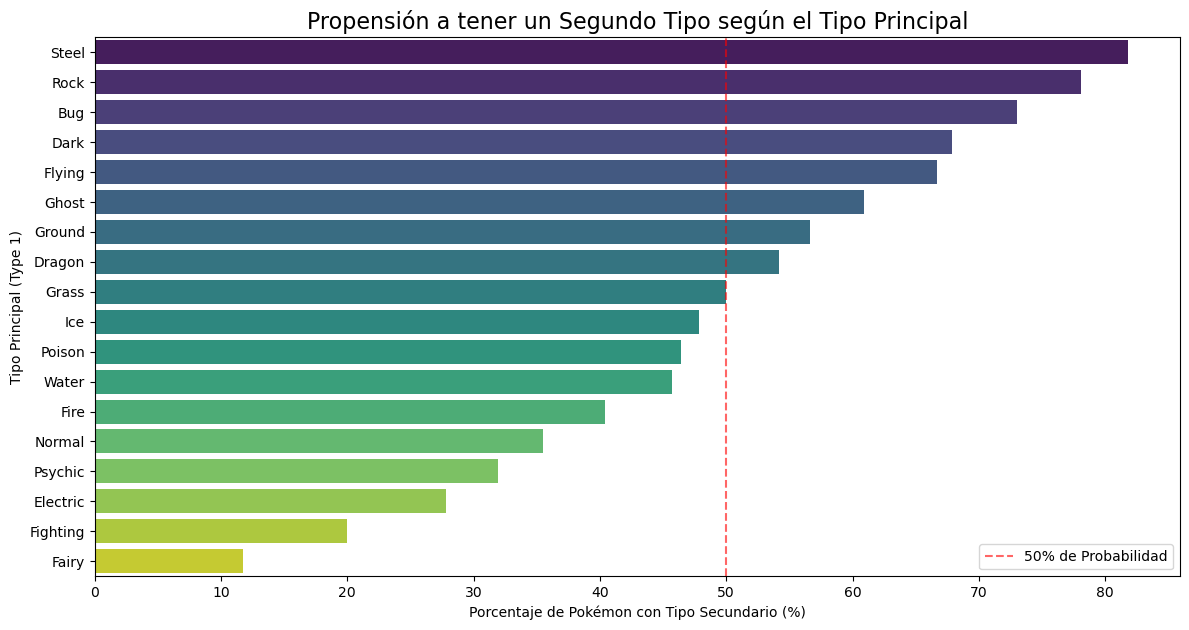

In [22]:
# Creamos un flag de si tiene Tipo 2:
df_limpio['Tiene_Type2'] = df_limpio['Type2'].notna()

# Calculamos el porcentaje de Pokémon con segundo tipo por cada Type1
prob_type2 = df_limpio.groupby('Type1')['Tiene_Type2'].mean().sort_values(ascending=False) * 100

# Graficamos
plt.figure(figsize=(14, 7))
sns.barplot(x=prob_type2.values, y=prob_type2.index, hue=prob_type2.index, palette='viridis', legend=False)

# Añadimos una línea vertical en el 50%
plt.axvline(50, color='red', linestyle='--', alpha=0.6, label='50% de Probabilidad')

plt.title('Propensión a tener un Segundo Tipo según el Tipo Principal', fontsize=16)
plt.xlabel('Porcentaje de Pokémon con Tipo Secundario (%)')
plt.ylabel('Tipo Principal (Type 1)')
plt.legend()
plt.show()